![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Aquí vamos a empezar con la importación de librerías
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

import joblib
import seaborn as sns
import matplotlib.pyplot as plt

En esta celda cargamos las librerìas necesarias para el desarrollo de la primera fase de este proyecto. Esto nos permitirá cargar y manipular los datos, construir nuestro pipeline de pre-procesamiento y entrenar nuestros primeros modelos basados en árboles, tambien podremos calibrar los hiperparámetros, evaluar el desempeño predictivo y exportar el modelo para su eventual publicación a través de una API.

In [3]:
# Aquí va nuestra celda para cargar datos de archivo .csv (esta viene sin cambios desde el ejemplo original)
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

Aquí cargamos nuestros datos de entrenamiento y prueba de acuerdo con las celdas inicials publicadas para este taller. Este conjunto de datos de entramiento contiene la variable "Popularity", el conjunto de prueba contiene las observaciones sobre las que generaremos las observaciones para la competencia.

In [4]:
# Aquí vamos con la visualización datos de entrenamiento (también sin cambio desde el modelo original)
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
# Aquí vamos con la visualización datos de test (también sin cambio desde el modelo original)
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [6]:
# Aquí vamos a comenzar con las dimensiones de los conjuntos de datos

print("Dimensiones dataTraining:", dataTraining.shape)
print("Dimensiones dataTesting:", dataTesting.shape)

Dimensiones dataTraining: (79800, 21)
Dimensiones dataTesting: (34200, 19)


El conjunto de datos de entrenamiento cuenta con 79,800 observaciones y 21 variables, mientras que el conjunto de prueba contiene 34,200 observaciones. A partir de la inspección inicial, se identificó que no existen valores faltantes en las variables, lo que simplifica el proceso de preprocesamiento. Las variables incluyen características numéricas relacionadas con propiedades acústicas de las canciones, así como variables categóricas como el género musical

In [7]:
# Aquí vamos con los tipos de datos y valores no nulos

dataTraining.info()

<class 'pandas.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        79800 non-null  int64  
 1   track_id          79800 non-null  str    
 2   artists           79800 non-null  str    
 3   album_name        79800 non-null  str    
 4   track_name        79800 non-null  str    
 5   duration_ms       79800 non-null  int64  
 6   explicit          79800 non-null  bool   
 7   danceability      79800 non-null  float64
 8   energy            79800 non-null  float64
 9   key               79800 non-null  int64  
 10  loudness          79800 non-null  float64
 11  mode              79800 non-null  int64  
 12  speechiness       79800 non-null  float64
 13  acousticness      79800 non-null  float64
 14  instrumentalness  79800 non-null  float64
 15  liveness          79800 non-null  float64
 16  valence           79800 non-null  float64
 17  temp

In [8]:
# Aquí vamos con la visión de valores faltantes

dataTraining.isnull().sum().sort_values(ascending=False)

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
popularity          0
dtype: int64

In [9]:
dataTraining.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
# Aquí vamos a comenzar con las estadísticas descriptivas de la variable objetivo

dataTraining['popularity'].describe()

count    79800.000000
mean        33.265301
std         22.330871
min          0.000000
25%         17.000000
50%         35.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

Text(0, 0.5, 'Frecuencia')

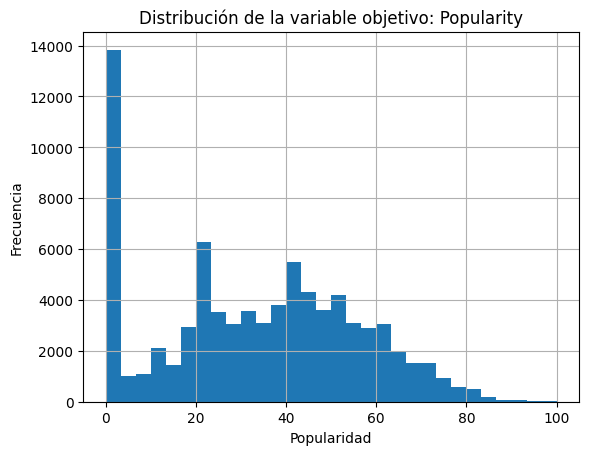

In [11]:
# Aquí veremos la distribución de la variable objetivo

dataTraining['popularity'].hist(bins=30)
plt.title('Distribución de la variable objetivo: Popularity')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

[Text(0.5, 1.0, 'Boxplot Popularidad de las Canciones'),
 Text(0.5, 0, 'Popularidad')]

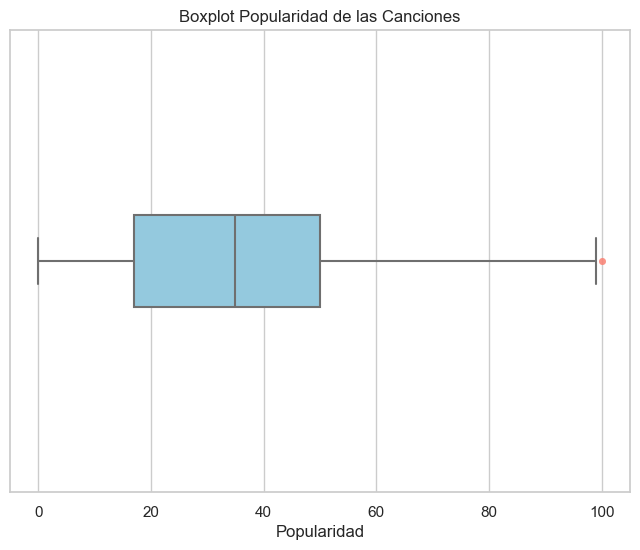

In [12]:
# Gráfico de cajas y bigotes para analizar la variable objetivo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x=dataTraining['popularity'], 
    color='skyblue',
    width=0.2,               
    linewidth=1.5,       
    fliersize=5,             
    flierprops={
        'marker': 'o', 
        'markerfacecolor': 'salmon', 
        'markeredgecolor': 'none', 
        'alpha': 0.6
    } 
)
ax.set(title='Boxplot Popularidad de las Canciones', xlabel='Popularidad')

Se analizó la variable objetivo popularity, la cual representa el nivel de popularidad de cada canción en una escala numérica. A partir de las estadísticas descriptivas y la visualización de su distribución, se confirmó que se trata de una variable continua, por lo que el problema fue abordado como una tarea de regresión.

In [13]:
# Aquí veremos la separación entre variables predictoras y variable objetivo

X = dataTraining.drop(columns=['popularity'])
y = dataTraining['popularity']

X_test = dataTesting.copy()

Text(0.5, 1.0, 'Correlograma de Variables Numéricas')

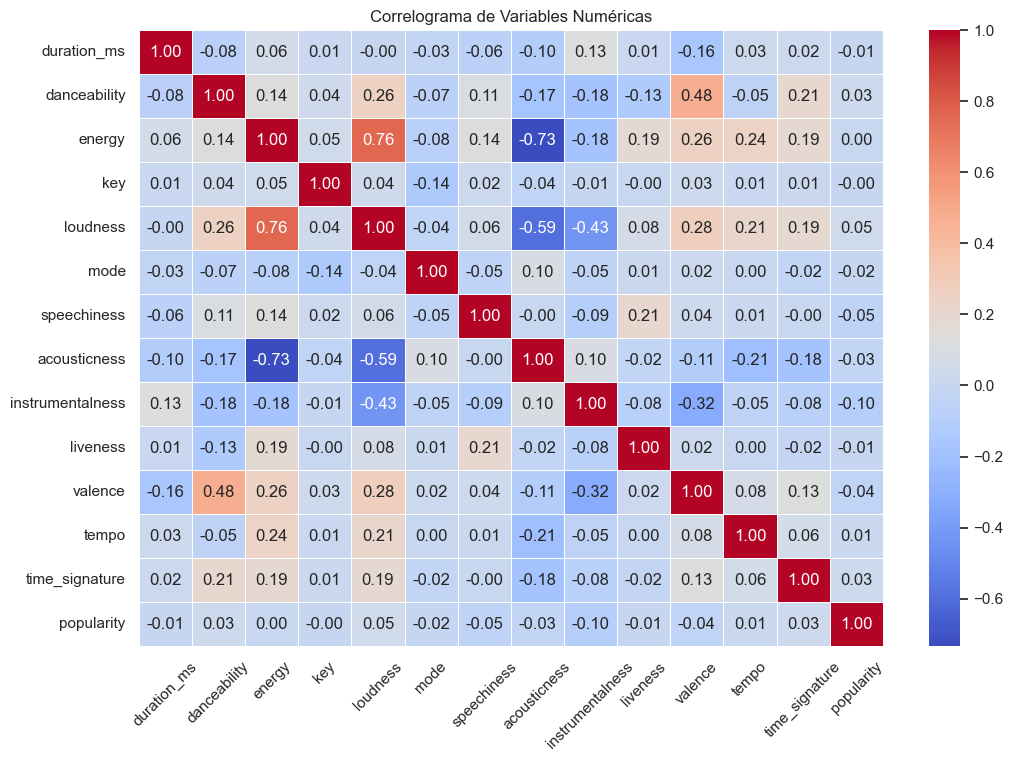

In [14]:
# Correlograma para analizar la correlación entre variables numéricas con seaborn

num_vars = dataTraining.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 8))
sns.heatmap(dataTraining[num_vars].corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', xticklabels=num_vars, yticklabels=num_vars)
plt.xticks(rotation=45)
plt.title('Correlograma de Variables Numéricas')


In [15]:
# Método mutual information para la selección de variables predictoras según su nivel de importancia con la variable objetivo
# Selección de variables numéricas para mutual information, excluir el indice de filas y la variable objetivo
num_vars = X.select_dtypes(include=['float64', 'int64']).columns
# Cálculo de mutual information
mi_scores = mutual_info_regression(X[num_vars], y)

Text(0.5, 1.0, 'Importancia de Variables según Mutual Information')

<Figure size 1000x600 with 0 Axes>

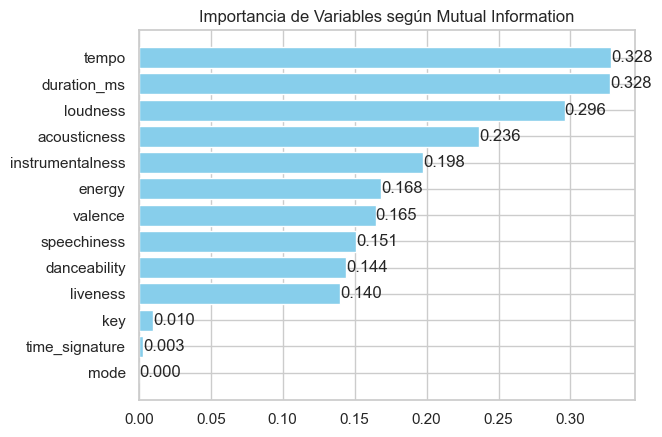

In [16]:
# Gráfico de importancia de las variables numéricas según mutual information
mi_scores_series = pd.Series(mi_scores, index=num_vars).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
bar_container = ax.barh(mi_scores_series.index, mi_scores_series.values, color='skyblue')
ax.invert_yaxis()
ax.bar_label(bar_container, fmt='%.3f')
plt.title('Importancia de Variables según Mutual Information')

In [17]:
# Aquí va la selección de variables para el modelo

numeric_features = [
    'duration_ms', 'danceability', 'loudness',
     'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo']

categorical_features = ['explicit', 'track_genre']

selected_features = numeric_features + categorical_features

X = X[selected_features]
X_test = X_test[selected_features]

Se sacaron las variables numéricas: loudness, key, time_signature, mode

Se seleccionaron variables numéricas asociadas a características acústicas de las canciones, tales como danceability, energy, tempo y valence, así como variables categóricas relevantes como explicit y track_genre. Se excluyeron variables como track_id, artists, album_name y track_name, debido a su alta cardinalidad y a que su inclusión requeriría técnicas más complejas de procesamiento de texto. Esta selección permitió construir un modelo inicial más eficiente y fácilmente interpretable.

In [18]:
# Aquí vamos a dividir nuestros datos en los conjuntos de entrenamiento y validación

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

Se construyó un pipeline que integra el preprocesamiento de los datos y el modelo predictivo. Para las variables numéricas se utilizó imputación mediante la mediana, mientras que para las variables categóricas se aplicó imputación por la moda seguida de una codificación one-hot. Este enfoque garantiza que las transformaciones se ajusten únicamente con los datos de entrenamiento y se apliquen de manera consistente a los datos de validación y prueba, evitando fugas de información.

In [19]:
# Este es nuestro pipeline de preprocesamiento para variables numéricas y categóricas

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)])

In [20]:
# Aquí vamos con el entrenamiento del modelo baseline

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        random_state=42,
        n_estimators=50,
        max_depth=10,
        n_jobs=-1))])

model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [21]:
# Aquí vamos predicciones sobre el conjunto de validación

y_pred_val = model_rf.predict(X_val)

In [22]:
# Aquí vamos con la evaluación del modelo baseline

mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2 = r2_score(y_val, y_pred_val)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 16.993590583969272
RMSE: 20.835862172004557
R2: 0.12192376390936033


l modelo baseline basado en Random Forest presentó un MAE de 16.99 y un RMSE de 20.84, lo que indica que, en promedio, el error absoluto de las predicciones es cercano a 17 unidades de popularidad. El coeficiente de determinación R² fue de 0.12, lo que sugiere que el modelo logra explicar aproximadamente el 12% de la variabilidad de la variable objetivo. Estos resultados evidencian que, si bien el modelo captura cierta información relevante, su capacidad predictiva inicial es limitada, lo que justifica la necesidad de calibrar los hiperparámetros.

In [23]:
# Aquí va nuestro espacio de búsqueda para calibración de hiperparámetros

param_dist = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]}

In [24]:
# Esta es una muestra para calibración

X_train_sample = X_train.sample(20000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [25]:
# Aquí haremos unas búsqueda aleatoria de hiperparámetros

param_dist = {
    'regressor__n_estimators': [30, 50, 80],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]}

random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist,
    n_iter=4,
    cv=2,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2)

random_search.fit(X_train_sample, y_train_sample)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [5, 10, ...], 'regressor__min_samples_leaf': [1, 2], 'regressor__min_samples_split': [2, 5], 'regressor__n_estimators': [30, 50, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

La calibración de hiperparámetros se realizó mediante RandomizedSearchCV, con el fin de explorar diferentes configuraciones del modelo de manera eficiente. Debido al tamaño del conjunto de datos y al costo computacional asociado, la búsqueda se llevó a cabo sobre una muestra de 20,000 observaciones del conjunto de entrenamiento. Este enfoque permitió reducir el tiempo de entrenamiento manteniendo una representación adecuada de los datos.

In [26]:
# Aquí haremos una evaluación del mejor modelo encontrado

best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_val)

mae_best = mean_absolute_error(y_val, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
r2_best = r2_score(y_val, y_pred_best)

print("MAE ajustado:", mae_best)
print("RMSE ajustado:", rmse_best)
print("R2 ajustado:", r2_best)

MAE ajustado: 16.349039790704996
RMSE ajustado: 20.27402681036747
R2 ajustado: 0.16863965591870245


El modelo calibrado presentó una mejora respecto al baseline en todas las métricas evaluadas. El MAE disminuyó a 16.34 y el RMSE a 20.26, lo que indica una reducción en el error de predicción. Asimismo, el coeficiente R² aumentó a 0.17, lo que refleja una mayor capacidad del modelo para explicar la variabilidad de la popularidad. Estos resultados confirman que la calibración de hiperparámetros contribuyó positivamente al desempeño del modelo.

In [27]:
# De acuerdo con nuestro resultado a aquí vamos con el reentrenamiento del mejor modelo con todos los datos de entrenamiento

best_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [28]:
# Aquí van nuestras predicciones finales para Kaggle

test_pred = best_model.predict(X_test)

y_pred = pd.DataFrame(test_pred, index=X_test.index, columns=['Popularity'])
y_pred.head()

,Popularity
0,35.365857
1,13.816370
2,0.872778
3,34.053421
4,34.053421


In [29]:
# Aquí guardamos el archivo que cargaremos en Kaggle

y_pred.to_csv('test_submission_file.csv', index_label='ID')

In [30]:
# Y aquí vamos a exportar el modelo final para disponibilización

joblib.dump(best_model, 'spotify_popularity_model.pkl')

['spotify_popularity_model.pkl']

**Conclusiones**
En comparación con el modelo baseline, el modelo calibrado mostró una mejora consistente en las métricas de desempeño. La reducción en MAE y RMSE indica predicciones más precisas, mientras que el incremento en R² sugiere una mejor capacidad explicativa. Por esta razón, el modelo calibrado fue seleccionado como el modelo final para la generación de predicciones y su posterior disponibilización mediante una API.

A pesar de la mejora obtenida tras la calibración, los valores de R² indican que el modelo aún tiene una capacidad limitada para explicar completamente la variabilidad de la popularidad. Esto sugiere que podrían existir variables adicionales relevantes o relaciones más complejas no capturadas por el modelo actual.

Se logró construir un modelo de regresión basado en Random Forest para predecir la popularidad de canciones, integrando el preprocesamiento y el modelo en un pipeline. La calibración de hiperparámetros permitió mejorar el desempeño respecto al modelo baseline, aunque aún existen oportunidades de mejora. Finalmente, el modelo fue entrenado sobre la totalidad de los datos y preparado para su disponibilización mediante una API.
